In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# **Creating Dataset**

In [ ]:
from sklearn.datasets import make_regression

x, y = make_regression(
    n_samples=10000,
    n_features=1,
    noise=10,
    random_state=42
)

print(x.shape)
print(y.shape)

(10000, 1)
(10000,)


<Axes: >

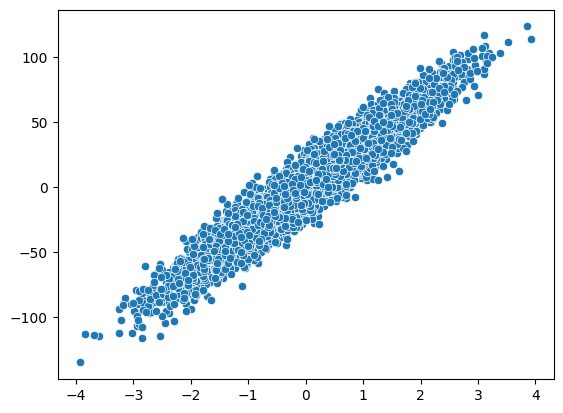

In [ ]:
sns.scatterplot(x=x.ravel(),y=y.ravel())

# **Using Simple Linear Regression Library**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
lr=LinearRegression()

In [ ]:
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=lr.predict(x_test)

In [ ]:
r2_score(y_test,y_pred)

0.9114233808640402

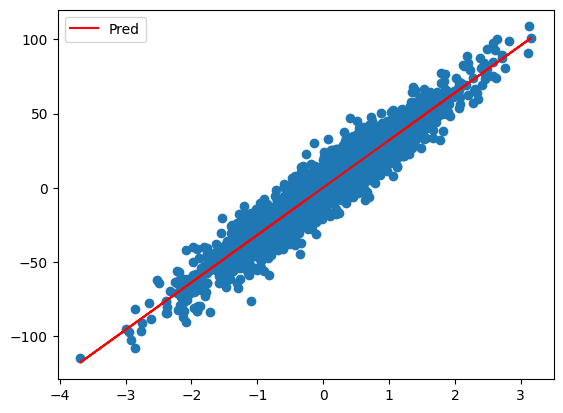

In [ ]:
plt.scatter(x_test,y_test)
plt.plot(x_test,y_pred,label="Pred",color='red')
plt.legend()

In [ ]:
print("m =", lr.coef_)
print("b =", lr.intercept_)

m = [31.89690635]
b = 0.16265720394167374


# **Using Own Linear Regression**

In [ ]:
class MyLr:

  def _init_(self):
    self.m=None
    self.b=None

  def fit(self,x,y):
    y_mean=y_train.ravel().mean()
    x_mean=x_train.ravel().mean()
    p=(x_train.ravel()-x_mean.ravel())*(y_train.ravel()-y_mean.ravel())
    q=(x_train-x_mean)**2
    self.m=p.sum()/q.sum()
    self.b=y_mean-self.m*x_mean

  def predict(self,x):
    return self.m*(x_test.ravel())+self.b


In [ ]:
mylr=MyLr()

In [ ]:
mylr.fit(x_train,y_train)

In [ ]:
y_pred_own=mylr.predict(x_test)

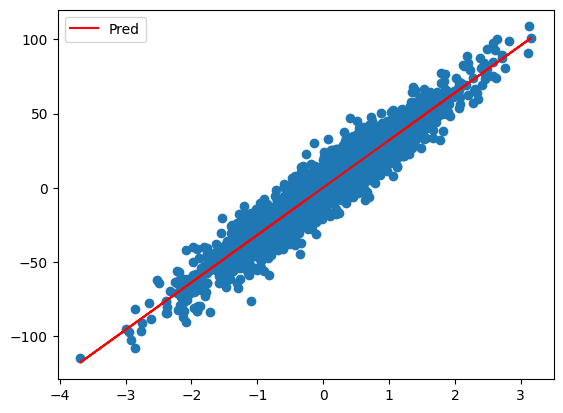

In [ ]:
plt.scatter(x_test,y_test)
plt.plot(x_test,y_pred_own,label="Pred",color='red')
plt.legend()

In [ ]:
r2_score(y_test,y_pred_own)

0.9114233808640402

In [ ]:
print("m =", mylr.m)
print("b =", mylr.b)

m = 31.896906348451118
b = 0.16265720394167377


# **Comparison**

In [ ]:
print('Value of sklearn m:', lr.coef_)
print('Value of own m:', mylr.m)

Value of sklearn m: [31.89690635]
Value of own m: 31.896906348451118


In [ ]:
print('Value of sklearn b:', lr.intercept_)
print('Value of own b:', mylr.b)

Value of sklearn b: 0.16265720394167374
Value of own b: 0.16265720394167377


In [ ]:
print("R2 score of sklean lr",r2_score(y_test,y_pred))
print("R2 score of own lr",r2_score(y_test,y_pred_own))

R2 score of sklean lr 0.9114233808640402
R2 score of own lr 0.9114233808640402
